# Dict Expander Example

This notebook reads `dictExpander.csv`, renames columns using the text after `#`, then parses dict/list strings stored in CSV cells.

In [7]:
import pandas as pd
import numpy as np
from pandas import Timestamp

csv_file = "dictExpander.csv"

In [8]:
def rename_columns_old(df):
    df.columns = [col.split('#')[-1].strip() if '#' in col else col.strip() for col in df.columns]
    return df

# def rename_columns(df):
#     df.columns = [col.split("#")[-1].strip() if "#" in col else col.strip() for col in df.columns]

#     for col in df.columns.copy():
#         if not isinstance(df[col].iloc[0], str) or df[col].iloc[0][0] not in "[{":
#             continue

#         values = df[col].apply(lambda s: eval(s, {"Timestamp": pd.Timestamp, "pd": pd, "np": np}))

#         if isinstance(values.iloc[0], dict):
#             df = pd.concat([df.drop(columns=col), pd.json_normalize(values).add_prefix(f"{col}.")], axis=1)
#         elif isinstance(values.iloc[0], list):
#             df = pd.concat([df.drop(columns=col), pd.DataFrame(values.tolist()).add_prefix(f"{col}.")], axis=1)

#     return df

def rename_columns(df):
    df.columns = [c.split("#")[-1].strip() for c in df.columns]
    for c in df.columns[df.iloc[0].astype(str).str[0].isin(["[", "{"])]:
        v = df[c].map(eval)
        df = df.drop(columns=c).join(pd.DataFrame(v.tolist()).add_prefix(f"{c}."))
    return df


In [9]:
raw = pd.read_csv(csv_file, comment=";")
raw = rename_columns_old(raw)
# raw
raw.dic[0]

"{'timestamp': Timestamp('2026-05-12 16:45:32.378986'), 'x': 0.24766475634287333, 'y': 0.6966215242778948, 'label': 'one dict in one csv cell'}"

In [10]:
df = rename_columns(raw)
df.head()

NameError: name 'Timestamp' is not defined

In [ ]:
df.columns

Index(['now', 'repeat', 'dic.timestamp', 'dic.x', 'dic.y', 'dic.label',
       'lis.0', 'lis.1', 'lis.2'],
      dtype='str')

<Axes: xlabel='repeat'>

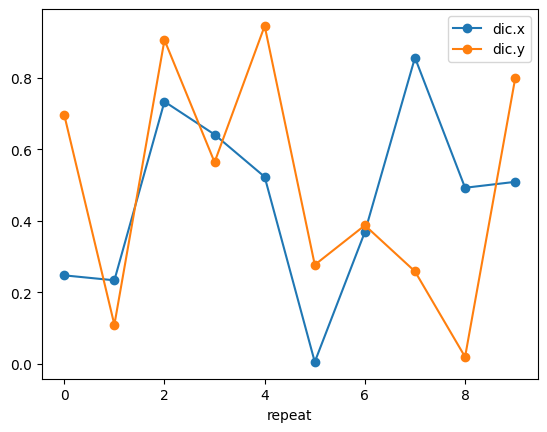

In [ ]:
df.plot(x="repeat", y=["dic.x", "dic.y"], marker="o")